C:\Users\ernan\AppData\Local\Temp\ipykernel_10556\3288682431.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\ernan\AppData\Local\Temp\ipykernel_10556\3288682431.py:41: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.savefig("dynamic_pipeline_example.png")
f:\Project - Copy\ollama-notes\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


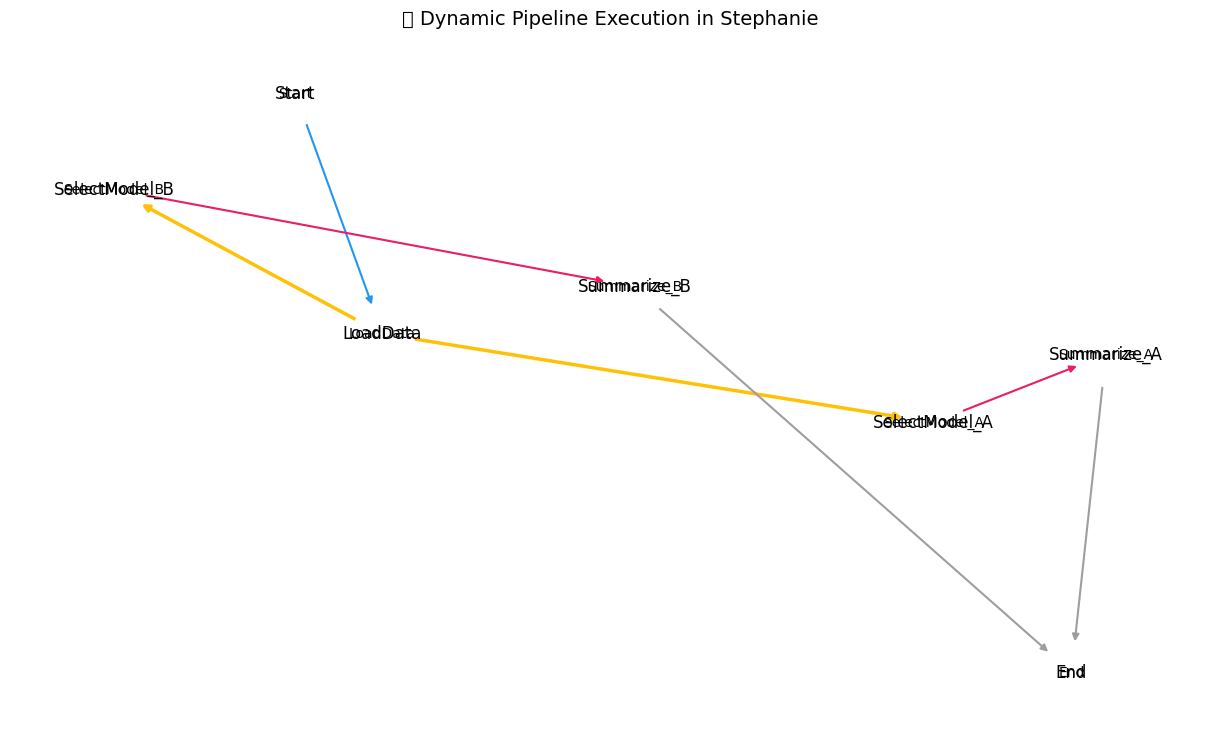

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

# Define pipeline graph
G = nx.DiGraph()

# Define steps and dynamic branches
steps = [
    ("Start", "LoadData", "loader"),
    ("LoadData", "SelectModel_A", "scorer"),
    ("LoadData", "SelectModel_B", "scorer"),
    ("SelectModel_A", "Summarize_A", "summarizer"),
    ("SelectModel_B", "Summarize_B", "summarizer"),
    ("Summarize_A", "End", "generic"),
    ("Summarize_B", "End", "generic")
]

# Add to graph
for src, dst, step_type in steps:
    G.add_edge(src, dst, type=step_type)

# Layout and styles
pos = nx.spring_layout(G, seed=42)
step_colors = {
    "loader": "#2196F3",
    "scorer": "#FFC107",
    "summarizer": "#E91E63",
    "generic": "#9E9E9E"
}
edge_colors = [step_colors.get(G.edges[e]['type'], "#9E9E9E") for e in G.edges]
edge_widths = [2.5 if "Model" in e[1] else 1.5 for e in G.edges]

# Draw
plt.figure(figsize=(12, 7))
nx.draw(G, pos, with_labels=True, node_color="#FFFFFF", node_size=2000, edge_color=edge_colors, width=edge_widths)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("🔄 Dynamic Pipeline Execution in Stephanie", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("dynamic_pipeline_example.png")
plt.show()
